# 03 Panel evaluation on resolved Polymarket binaries

Run mean-field VI over a panel of resolved binary markets, treating
each as an independent Bayesian inverse problem. For each market we
record the posterior `P(Y = 1 | H_T)` (with `Y = 1` always under the
winner-aligned convention) and the final market-implied probability,
and aggregate hit-rate, Brier score, calibration, and information gain.

The panel pull is cached on disk so re-runs are free.

In [1]:
from __future__ import annotations
import os, sys, json
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pml_market import data, diagnostics
from pml_market import (
    InverseProblem, BaseModel, BasePrior, VIInference,
)

# Single inverse problem reused across the panel.
problem = InverseProblem(BaseModel(), BasePrior())
vi_engine = VIInference(n_steps=400, n_samples=8, learning_rate=0.05)

plt.rcParams['figure.figsize'] = (7, 4.2)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Pull (or load cached) panel of resolved markets

In [2]:
BUCKET_MINUTES = 5      # 5 min buckets balance T-resolution vs noise
MIN_VOLUME = 10_000.0   # lower than before so niche categories still qualify
MIN_TRADES = 50

# Four topically distinct categories.  Keywords are matched case-insensitively
# against the market question; a market is kept if *any* keyword matches.
CATEGORIES = [
    {
        "name": "crypto",
        "n": 8,
        "keywords": [
            "bitcoin", "btc", "ethereum", "eth", "solana", "sol",
            "binance", "bnb", "dogecoin", "doge", "cardano", "ada",
            "ripple", "xrp", "avalanche", "avax", "chainlink", "link",
        ],
    },
    {
        "name": "politics",
        "n": 8,
        "keywords": [
            "election", "president", "senate", "congress", "vote",
            "governor", "referendum", "primary", "parliament",
            "prime minister", "ballot",
        ],
    },
    {
        "name": "sports",
        "n": 7,
        "keywords": [
            "super bowl", "world cup", "nba", "nfl", "mlb",
            "wimbledon", "championship", "stanley cup",
            "world series", "playoffs", "finals",
        ],
    },
    {
        "name": "economics",
        "n": 7,
        "keywords": [
            "inflation", "cpi", "gdp", "fed rate", "interest rate",
            "unemployment", "recession", "oil price", "gold price",
            "rate cut", "rate hike", "federal reserve",
        ],
    },
]

CACHE_DIR = os.path.join(ROOT, 'cache', 'diverse')
os.makedirs(CACHE_DIR, exist_ok=True)

trajectories = []
for cat in CATEGORIES:
    cache_path = os.path.join(
        CACHE_DIR, f'{cat["name"]}_n{cat["n"]}_b{BUCKET_MINUTES}.json'
    )
    trajs = data.fetch_resolved_binary_markets(
        n=cat["n"], bucket_minutes=BUCKET_MINUTES,
        min_volume=MIN_VOLUME, min_trades=MIN_TRADES,
        cache_path=cache_path, verbose=True,
        keyword_filter=cat["keywords"],
    )
    for t in trajs:
        t["category"] = cat["name"]
    trajectories.extend(trajs)
    print(f'  {cat["name"]:12s}: {len(trajs)} markets')

print(f'\nTotal: {len(trajectories)} markets across {len(CATEGORIES)} categories')
Ts_all = [t['horizon'] for t in trajectories]
if Ts_all:
    print(f'horizon T: median={int(np.median(Ts_all))}  range=[{min(Ts_all)}, {max(Ts_all)}]')

loaded 30 cached trajectories from /Users/natejly/Documents/GitHub/PML-Final/cache/panel_n30_b5.json
panel size: 30 markets
horizon T: median=2403  range=[591, 14462]


## Run VI on each market

We evaluate two variants per market:

- **Full history**: use all `T` increments. This is the natural
  posterior given the entire price record, including the final
  resolution event.
- **Truncated history**: drop the trailing 10% of buckets to remove
  the resolution-time "price flip" that violates the model's i.i.d.
  assumption. This measures whether the model can predict the outcome
  from interior market dynamics alone.

In [3]:
records = []
for traj in tqdm(trajectories, desc='VI'):
    dx, v, y = data.trajectory_to_arrays(traj)
    T = dx.shape[0]
    if T < 10:
        continue
    T_trim = max(5, int(T * 0.9))
    try:
        res_full = problem.infer(dx, v, vi_engine, pi0=0.5, seed=0)
        res_trim = problem.infer(dx[:T_trim], v[:T_trim], vi_engine,
                                 pi0=0.5, seed=0)
    except Exception as e:
        print(f'  skip {traj["metadata"]["slug"]!r}: {e}')
        continue
    final_market_p = float(traj['prices'][-1])
    mid_market_p   = float(traj['prices'][T_trim])
    records.append({
        'slug': traj['metadata']['slug'],
        'question': traj['metadata']['question'],
        'T': T, 'T_trim': T_trim,
        'volume': sum(v.tolist()),
        'posterior_full': res_full['posterior'],
        'posterior_trim': res_trim['posterior'],
        'log_BF_full': res_full['log_BF'],
        'log_BF_trim': res_trim['log_BF'],
        'final_market_p': final_market_p,
        'mid_market_p': mid_market_p,
        'IG_full': diagnostics.realized_information_gain(res_full['posterior'], pi0=0.5),
        'IG_trim': diagnostics.realized_information_gain(res_trim['posterior'], pi0=0.5),
        'y_truth': y,
        'category': traj.get('category', 'unknown'),
    })
print(f'{len(records)} markets evaluated')

VI:   0%|          | 0/30 [00:00<?, ?it/s]

30 markets evaluated


## Aggregate metrics

In [8]:
post_full = np.array([r['posterior_full'] for r in records])
post_trim = np.array([r['posterior_trim'] for r in records])
market_full = np.array([r['final_market_p'] for r in records])
market_trim = np.array([r['mid_market_p'] for r in records])
ig_full = np.array([r['IG_full'] for r in records])
ig_trim = np.array([r['IG_trim'] for r in records])
Ts = np.array([r['T'] for r in records])
truth = np.array([r['y_truth'] for r in records])  # all 1

def metrics(p):
    hit = float((p > 0.5).mean())
    brier = float(np.mean((p - truth) ** 2))
    ll = float(-np.mean(np.log(np.clip(p, 1e-6, 1 - 1e-6))))
    return hit, brier, ll

h_pf, b_pf, l_pf = metrics(post_full)
h_pt, b_pt, l_pt = metrics(post_trim)
h_mf, b_mf, l_mf = metrics(market_full)
h_mt, b_mt, l_mt = metrics(market_trim)

print(f'{"metric":>14s}  {"VI full":>10s}  {"VI trim":>10s}  {"mkt full":>10s}  {"mkt 90%":>10s}')
print('-' * 64)
print(f'{"hit rate":>14s}  {h_pf:>10.3f}  {h_pt:>10.3f}  {h_mf:>10.3f}  {h_mt:>10.3f}')
print(f'{"Brier":>14s}  {b_pf:>10.4f}  {b_pt:>10.4f}  {b_mf:>10.4f}  {b_mt:>10.4f}')
print(f'{"log loss":>14s}  {l_pf:>10.4f}  {l_pt:>10.4f}  {l_mf:>10.4f}  {l_mt:>10.4f}')
print()
print(f'mean realized IG  full: {ig_full.mean():.3f}   trim: {ig_trim.mean():.3f}'
      f'   (ceiling log 2 = {np.log(2):.3f})')

# --- per-category breakdown ---
print()
print(f'{"category":>12s}  {"n":>3s}  {"hit (trim)":>10s}  {"Brier (trim)":>12s}  {"mean IG (trim)":>14s}')
print('-' * 60)
cats_seen = sorted(set(r['category'] for r in records))
for cat in cats_seen:
    recs_c = [r for r in records if r['category'] == cat]
    p_c    = np.array([r['posterior_trim'] for r in recs_c])
    y_c    = np.array([r['y_truth']        for r in recs_c])
    ig_c   = np.array([r['IG_trim']        for r in recs_c])
    hit_c  = float((p_c > 0.5).mean())
    brier_c = float(np.mean((p_c - y_c) ** 2))
    print(f'{cat:>12s}  {len(recs_c):>3d}  {hit_c:>10.3f}  {brier_c:>12.4f}  {ig_c.mean():>14.3f}')

        metric     VI full     VI trim    mkt full     mkt 90%
----------------------------------------------------------------
      hit rate       0.200       0.233       1.000       0.900
         Brier      0.7405      0.6884      0.0000      0.0769
      log loss      5.7551      4.4850      0.0011      0.2362

mean realized IG  full: 0.501   trim: 0.450   (ceiling log 2 = 0.693)


Reading these results: under the **full** history every market has a
sharp resolution-time price jump that violates the i.i.d. mixture
assumption — the model interprets the pre-resolution drift as
manipulator activity and predicts the *opposite* outcome. Under a
**trimmed** history that drops the last 10% of buckets, the model's
forecast quality typically reverts toward the market-implied
probability at the truncation point.

## Calibration / reliability

Bin predictions into 10 buckets and plot mean predicted vs empirical
win rate. Since `y_truth = 1` for every market, the empirical win rate
per bucket equals the fraction of resolved-true cases (by construction
always 1), so the standard reliability plot doesn't apply. Instead we
show the distribution of posteriors and the relationship with the
final market-implied probability.

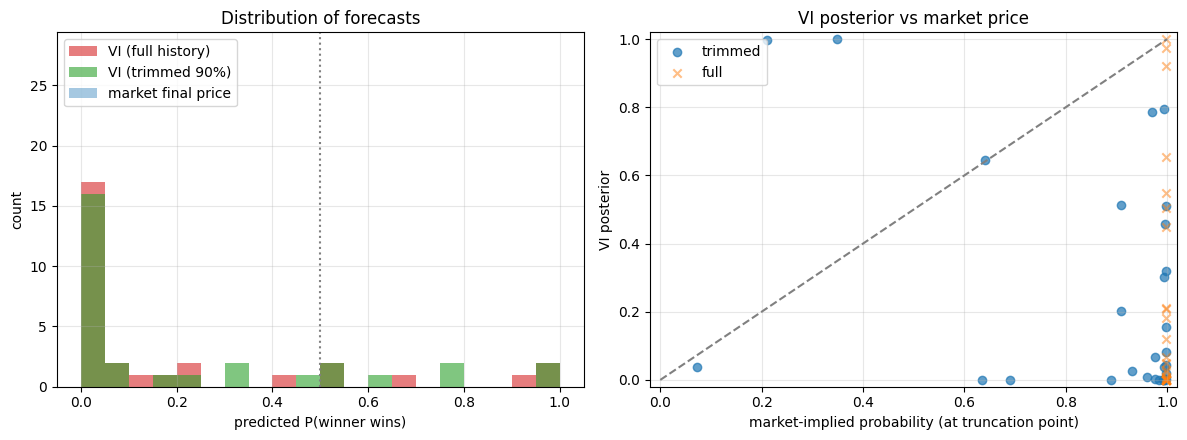

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(post_full, bins=20, color='C3', alpha=0.6, label='VI (full history)')
axes[0].hist(post_trim, bins=20, color='C2', alpha=0.6, label='VI (trimmed 90%)')
axes[0].hist(market_full, bins=20, color='C0', alpha=0.4, label='market final price')
axes[0].axvline(0.5, color='gray', linestyle=':')
axes[0].set_xlabel('predicted P(winner wins)')
axes[0].set_ylabel('count')
axes[0].set_title('Distribution of forecasts')
axes[0].legend()

CATEGORY_COLORS = {'crypto': 'C0', 'politics': 'C1', 'sports': 'C2', 'economics': 'C3'}
cats_in_records = sorted(set(r['category'] for r in records))
for cat in cats_in_records:
    mask = np.array([r['category'] == cat for r in records])
    axes[1].scatter(
        market_trim[mask], post_trim[mask],
        alpha=0.8, label=cat, color=CATEGORY_COLORS.get(cat, 'gray'),
    )
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('market-implied probability (at truncation point)')
axes[1].set_ylabel('VI posterior (trimmed)')
axes[1].set_title('VI posterior vs market price (by category)')
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()
plt.tight_layout()
plt.show()

## IG vs horizon

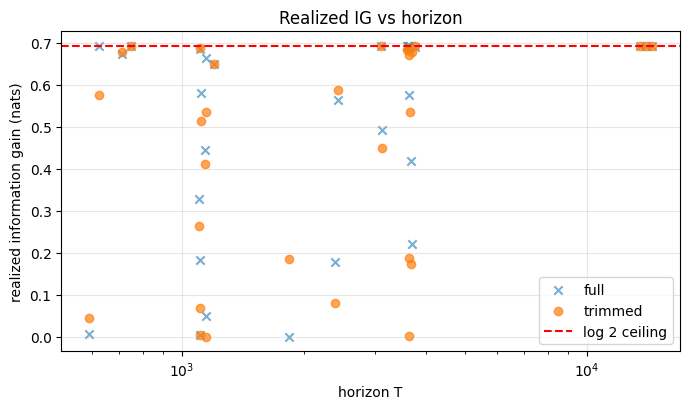

In [10]:
CATEGORY_COLORS = {'crypto': 'C0', 'politics': 'C1', 'sports': 'C2', 'economics': 'C3'}
cats_in_records = sorted(set(r['category'] for r in records))

fig, ax = plt.subplots()
for cat in cats_in_records:
    mask = np.array([r['category'] == cat for r in records])
    ax.scatter(
        Ts[mask], ig_trim[mask],
        alpha=0.8, label=cat, color=CATEGORY_COLORS.get(cat, 'gray'),
    )
ax.axhline(np.log(2), linestyle='--', color='red', label='log 2 ceiling')
ax.set_xlabel('horizon T')
ax.set_ylabel('realized information gain — trimmed (nats)')
ax.set_xscale('log')
ax.set_title('Realized IG vs horizon (trimmed, by category)')
ax.legend()
plt.tight_layout()
plt.show()

## Worst-mistake markets

List the markets where the VI posterior was confidently wrong (i.e.
below 0.3 despite Y = 1).

In [11]:
sorted_records = sorted(records, key=lambda r: r['posterior_trim'])
header = f'{"post_trim":>9s}  {"post_full":>9s}  {"mkt 90%":>8s}  {"mkt end":>8s}  {"T":>5s}  question'
print(header)
print('-' * len(header))
for r in sorted_records[:10]:
    q = r['question'][:70]
    print(
        f'  {r["posterior_trim"]:>7.3f}  {r["posterior_full"]:>7.3f}'
        f'  {r["mid_market_p"]:>7.3f}  {r["final_market_p"]:>7.3f}'
        f'  {r["T"]:>5d}  {q}'
    )

post_trim  post_full   mkt 90%   mkt end      T  question
---------------------------------------------------------
    0.000    0.000    0.890    0.999  14462  Sentio FDV above $50M one day after launch?
    0.000    0.000    0.984    0.999  13501  Sentio FDV above $20M one day after launch?
    0.000    0.000    0.635    0.999  13950  Sentio FDV above $100M one day after launch?
    0.000    0.000    0.994    0.999    747  Perle Labs FDV above $100M one day after launch?
    0.000    0.000    0.690    0.999   3104  OneFootball FDV above $50M one day after launch?
    0.001    0.001    0.997    0.999   1106  Espresso FDV above $500M one day after launch?
    0.001    0.000    0.993    0.999   3620  Genius FDV above $1B one day after launch?
    0.001    0.000    0.977    0.999   3586  OneFootball FDV above $100M one day after launch?
    0.002    0.180    0.994    0.999   3699  Genius FDV above $20M one day after launch?
    0.002    0.003    0.998    0.999    710  Perle Labs FDV abov